# Cls 2. Intro to PyTorch. CNNs

In [2]:
import torch 

In [3]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "1"

### Torch
1. Autograd  
2. Accelerator support 

In [5]:
x = torch.tensor([0, 1, 4], device='cpu', dtype=float)

In [6]:
y = torch.tensor([0, 2, 3], device="cpu", dtype=float)

In [7]:
x + y

tensor([0., 3., 7.], dtype=torch.float64)

## MLP

In [8]:
from torch import nn
from torchinfo import summary

In [9]:
class MLP(nn.Module):
    def __init__(self, d_in, d_out, d_hidden, depth=8):
        super().__init__()

        self.layers = nn.ModuleList([
            nn.Linear(d_in, d_hidden),
        ])

        for i in range(depth - 1):
            self.layers.append(nn.Linear(d_hidden, d_hidden))

        self.head = nn.Linear(d_hidden, d_out)
        self.relu = nn.ReLU()
        self.sigm = nn.Sigmoid()

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
            x = self.relu(x)

        x = self.head(x)
        x = self.sigm(x)

        return x

In [10]:
model = MLP(d_in=2, d_out=1, d_hidden=10, depth=10)

In [11]:
summary(model)

Layer (type:depth-idx)                   Param #
MLP                                      --
├─ModuleList: 1-1                        --
│    └─Linear: 2-1                       30
│    └─Linear: 2-2                       110
│    └─Linear: 2-3                       110
│    └─Linear: 2-4                       110
│    └─Linear: 2-5                       110
│    └─Linear: 2-6                       110
│    └─Linear: 2-7                       110
│    └─Linear: 2-8                       110
│    └─Linear: 2-9                       110
│    └─Linear: 2-10                      110
├─Linear: 1-2                            11
├─ReLU: 1-3                              --
├─Sigmoid: 1-4                           --
Total params: 1,031
Trainable params: 1,031
Non-trainable params: 0

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
data = pd.read_csv("data/cls1/points.csv", sep=' ', names=['x', 'y', 'cls'])
data.head()

,x,y,cls
0,1.699885,1.546782,1
1,1.641367,2.506392,1
2,2.408797,1.430931,1
3,3.255215,1.792221,1
4,2.361248,1.980791,1


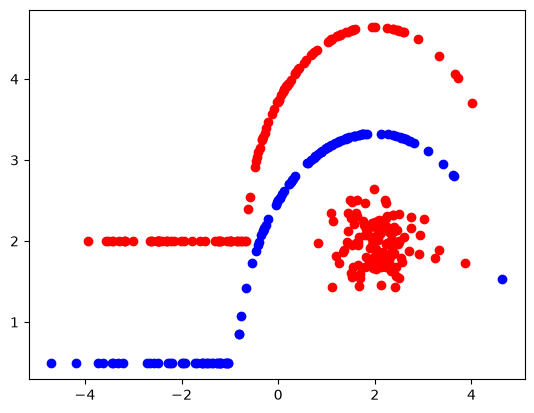

In [14]:
plt.scatter(*data[data['cls'] == 1].values[:, :2].T, c='red')
plt.scatter(*data[data['cls'] == 0].values[:, :2].T, c='blue')
plt.show()

### Train

In [26]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [27]:
x = torch.tensor(data[['x', 'y']].values, dtype=torch.float32)
x = (x - x.mean(axis=0)) / x.std(axis=0)
y = torch.tensor(data['cls'].values, dtype=torch.float32)
y = y.unsqueeze(1)

In [33]:
x

tensor([[ 0.5924, -0.7942],
        [ 0.5604,  0.0737],
        [ 0.9801, -0.8990],
        [ 1.4429, -0.5722],
        [ 0.9541, -0.4017],
        [ 0.8684,  0.0778],
        [ 0.8616, -0.6013],
        [ 0.8231, -0.6697],
        [ 0.5732, -0.3397],
        [ 0.7422, -0.5643],
        [ 0.5016,  0.0506],
        [ 0.6261, -0.1582],
        [ 0.5073, -0.6701],
        [ 0.3977, -0.5035],
        [ 0.6920, -0.5936],
        [ 0.7891, -0.5077],
        [ 0.9382, -0.4301],
        [ 0.9200, -0.6138],
        [ 0.8813, -0.2164],
        [ 0.8120, -0.2292],
        [ 0.5741, -0.8842],
        [ 0.9674, -0.5292],
        [ 0.7975, -0.3330],
        [ 1.0524, -0.5758],
        [ 0.7646, -0.4767],
        [ 1.0003, -0.7700],
        [ 0.4976, -0.7878],
        [ 1.0273, -0.3808],
        [ 0.5266, -0.1967],
        [ 0.8489, -0.5015],
        [ 0.8294, -0.8709],
        [ 0.6400, -0.6722],
        [ 1.0887, -0.3344],
        [ 0.8938, -0.1070],
        [ 0.8323, -0.2352],
        [ 0.5676, -0

In [28]:
model = MLP(d_in=2, d_out=1, d_hidden=10, depth=10)
loss_fn = nn.BCELoss()
optim = torch.optim.Adam(model.parameters(), lr=1e-2)

In [29]:
n_steps = 1000
loss_history = []

for i in tqdm(range(n_steps)):
    y_pred = model(x)
    loss = loss_fn(y_pred, y)

    loss_history.append(loss.item())

    optim.zero_grad() 
    loss.backward() 
    optim.step()

  0%|          | 0/1000 [00:00<?, ?it/s]

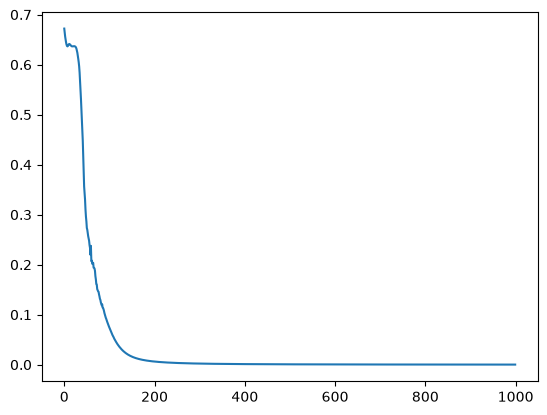

In [30]:
plt.plot(loss_history)

In [31]:
y_pred = model(x)

In [32]:
((y_pred > 0.5) == y).all()

tensor(True)

## Dataset & dataloader

In [135]:
import torch
import torchvision
from torchvision.transforms import v2


transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,))
])

# Class labels
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

In [154]:
training_set = torchvision.datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
training_loader = torch.utils.data.DataLoader(training_set, batch_size=96, shuffle=True)

In [155]:
batch = next(iter(training_loader))

In [156]:
import torch.nn as nn
import torch.nn.functional as F

# PyTorch models inherit from torch.nn.Module
class GarmentClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


model = GarmentClassifier()

In [157]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

model = model.to("cuda")

In [161]:
running_loss = 0.
last_loss = 0.

loss_history = []

n_epochs = 5

for n in range(n_epochs):
    for i, data in tqdm(enumerate(training_loader)):
        # Every data instance is an input + label pair
        inputs, labels = data

        inputs = inputs.to("cuda")
        labels = labels.to("cuda")

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs)

        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i == len(training_loader) - 1:
            last_loss = running_loss / 1000 # loss per batch
            print(f'  batch {i + 1} loss: {last_loss}')
            loss_history.append(last_loss)
            running_loss = 0.

0it [00:00, ?it/s]

  batch 625 loss: 0.3568241490125656


0it [00:00, ?it/s]

  batch 625 loss: 0.3326597792804241


0it [00:00, ?it/s]

  batch 625 loss: 0.31220454558730126


0it [00:00, ?it/s]

KeyboardInterrupt: 